In [1]:
# ============================================================
# 0. Установка и импорт библиотек
# ============================================================

# !pip install umap-learn pacmap trimap phate scikit-learn matplotlib seaborn

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from sklearn.manifold import TSNE
import umap.umap_ as umap
import pacmap
import trimap
import phate


In [3]:
# Общие настройки визуализаций
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (6, 5)


In [4]:
# ============================================================
# 1. Загрузка датасета и базовый препроцессинг
# ============================================================

# Для демонстрации возьмём стандартный MNIST (784‑мерный),
# но можно заменить на другой набор (например, digits / fashion_mnist).

from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X_raw = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

# Для ускорения возьмём подвыборку
n_samples = 4000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_raw), size=n_samples, replace=False)

X_raw = X_raw[idx]
y = y[idx]

X_std = StandardScaler().fit_transform(X_raw)

print("Форма данных:", X_raw.shape)


Форма данных: (4000, 784)


In [5]:
# ============================================================
# 2. Вспомогательные функции: замер времени, отрисовка, метрики
# ============================================================

def embed_and_time(method_name, embed_func, X, **kwargs):
    """
    Унифицированный запуск метода уменьшения размерности.
    embed_func(X, **kwargs) -> Z (n_samples x 2)
    """
    t0 = time.time()
    Z = embed_func(X, **kwargs)
    dt = time.time() - t0
    print(f"{method_name}: {dt:.2f} s")
    return Z, dt


def plot_embedding(Z, labels, title):
    plt.figure()
    sc = plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=8, cmap="tab10", alpha=0.8)
    plt.colorbar(sc, label="label")
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()


def knn_preservation(X_high, X_low, n_neighbors=15):
    """
    Доля общих соседей между исходным и низкоразмерным пространством.
    """
    nn_high = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X_high)
    nn_low = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X_low)

    ind_high = nn_high.kneighbors(return_distance=False)[:, 1:]
    ind_low = nn_low.kneighbors(return_distance=False)[:, 1:]

    # пересечение списков соседей
    overlaps = []
    for i in range(X_high.shape[0]):
        overlap = len(np.intersect1d(ind_high[i], ind_low[i])) / n_neighbors
        overlaps.append(overlap)
    return float(np.mean(overlaps))


t-SNE: 36.53 s


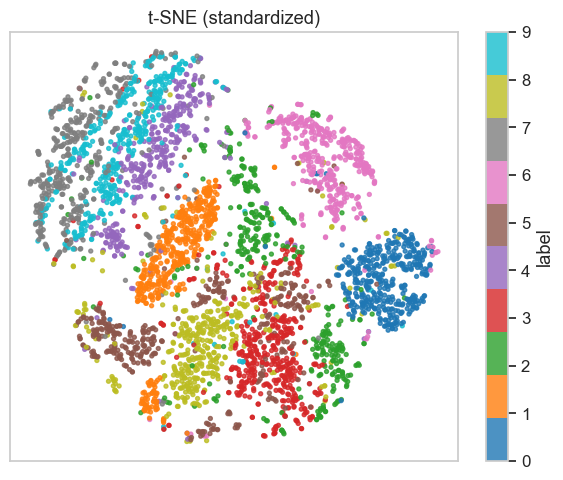

e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: 52.66 s


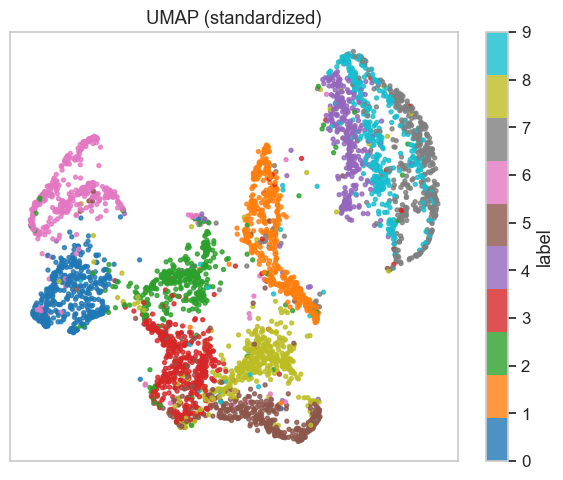

In [6]:
# ============================================================
# 3. t-SNE и UMAP (базовое сравнение)
# ============================================================

# 3.1 t-SNE
Z_tsne, t_tsne = embed_and_time(
    "t-SNE",
    lambda X, **kw: TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        max_iter=1000,
        init="pca",
        random_state=42,
    ).fit_transform(X),
    X_std,
)

plot_embedding(Z_tsne, y, "t-SNE (standardized)")

# 3.2 UMAP
Z_umap, t_umap = embed_and_time(
    "UMAP",
    lambda X, **kw: umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42,
    ).fit_transform(X),
    X_std,
)

plot_embedding(Z_umap, y, "UMAP (standardized)")


TriMAP: 26.56 s


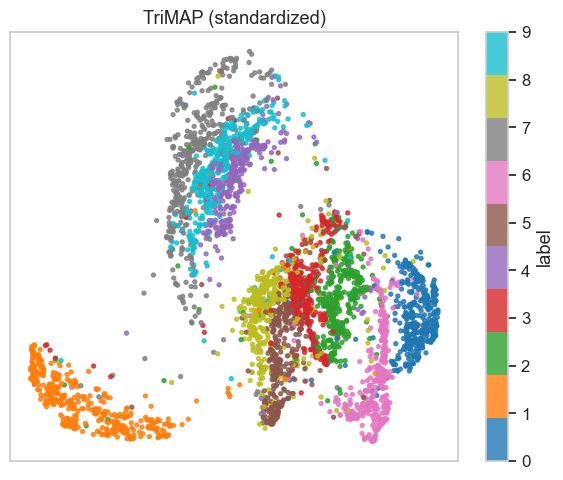

PaCMAP: 5.29 s


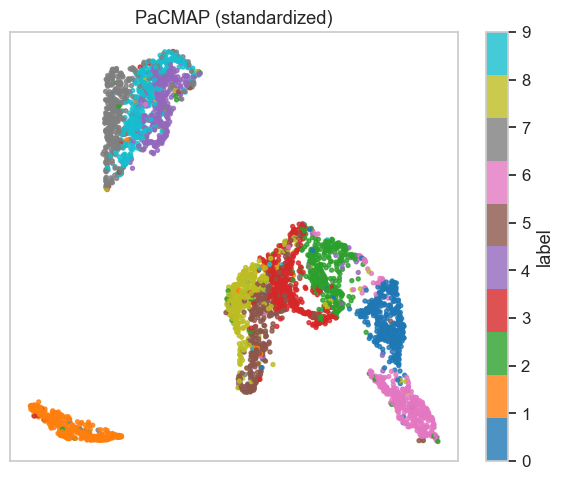

e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\phate\phate.py:208: FutureWarning: k is deprecated. Please use knn in future.
  warnings.warn("k is deprecated. Please use knn in future.", FutureWarning)


    SGD-MDS may not have converged: stress changed by 1.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
PHATE: 18.63 s


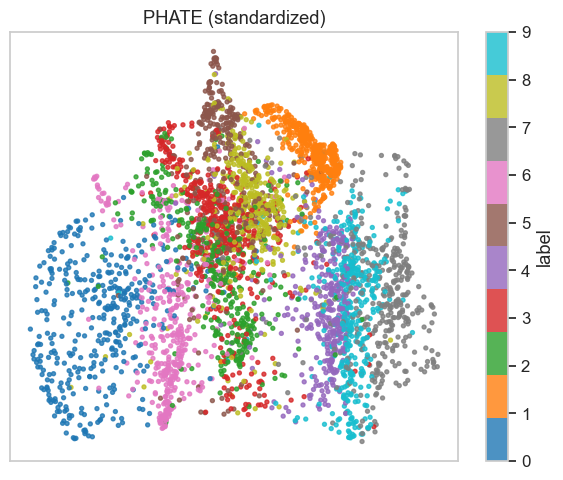

In [ ]:
# ============================================================
# 4. TriMAP, PaCMAP, PHATE
# ============================================================

# 4.1 TriMAP
Z_trimap, t_trimap = embed_and_time(
    "TriMAP",
    lambda X, **kw: trimap.TRIMAP(
        n_dims=2,
        n_inliers=15,
        n_outliers=20,
        n_random=5,
        verbose=False,
    ).fit_transform(X),
    X_std,
)
plot_embedding(Z_trimap, y, "TriMAP (standardized)")


# 4.2 PaCMAP
Z_pacmap, t_pacmap = embed_and_time(
    "PaCMAP",
    lambda X, **kw: pacmap.PaCMAP(
        n_components=2,
        n_neighbors=15,
        MN_ratio=0.5,
        FP_ratio=2.0,
        random_state=42,
    ).fit_transform(X),
    X_std,
)
plot_embedding(Z_pacmap, y, "PaCMAP (standardized)")


# 4.3 PHATE
phate_op = phate.PHATE(
    n_components=2,
    k=15,
    t="auto",
    random_state=42,
    verbose=False,
)
Z_phate, t_phate = embed_and_time(
    "PHATE", lambda X, **kw: phate_op.fit_transform(X), X_std
)
plot_embedding(Z_phate, y, "PHATE (standardized)")


In [9]:
# ============================================================
# 5. Количественное сравнение: silhouette и сохранение соседей
# ============================================================

def evaluate_embedding(Z, name, X_high, labels):
    sil = silhouette_score(Z, labels)
    knn = knn_preservation(X_high, Z, n_neighbors=15)
    print(f"{name}: silhouette={sil:.3f}, KNN-preservation={knn:.3f}")
    return sil, knn


results = {}

results["t-SNE"] = evaluate_embedding(Z_tsne, "t-SNE", X_std, y)
results["UMAP"] = evaluate_embedding(Z_umap, "UMAP", X_std, y)
results["TriMAP"] = evaluate_embedding(Z_trimap, "TriMAP", X_std, y)
results["PaCMAP"] = evaluate_embedding(Z_pacmap, "PaCMAP", X_std, y)
results["PHATE"] = evaluate_embedding(Z_phate, "PHATE", X_std, y)


t-SNE: silhouette=0.138, KNN-preservation=0.394
UMAP: silhouette=0.208, KNN-preservation=0.302
TriMAP: silhouette=0.200, KNN-preservation=0.297
PaCMAP: silhouette=0.225, KNN-preservation=0.272
PHATE: silhouette=0.078, KNN-preservation=0.197


In [10]:
# ============================================================
# 6. Сводная таблица по времени и метрикам
# ============================================================

import pandas as pd

rows = []
rows.append(
    dict(
        method="t-SNE",
        time=t_tsne,
        silhouette=results["t-SNE"][0],
        knn_pres=results["t-SNE"][1],
    )
)
rows.append(
    dict(
        method="UMAP",
        time=t_umap,
        silhouette=results["UMAP"][0],
        knn_pres=results["UMAP"][1],
    )
)
rows.append(
    dict(
        method="TriMAP",
        time=t_trimap,
        silhouette=results["TriMAP"][0],
        knn_pres=results["TriMAP"][1],
    )
)
rows.append(
    dict(
        method="PaCMAP",
        time=t_pacmap,
        silhouette=results["PaCMAP"][0],
        knn_pres=results["PaCMAP"][1],
    )
)
rows.append(
    dict(
        method="PHATE",
        time=t_phate,
        silhouette=results["PHATE"][0],
        knn_pres=results["PHATE"][1],
    )
)

df = pd.DataFrame(rows)
df


,method,time,silhouette,knn_pres
0,t-SNE,36.532999,0.138447,0.394367
1,UMAP,52.662553,0.208083,0.301717
2,TriMAP,26.561368,0.200160,0.297500
3,PaCMAP,5.287687,0.224747,0.271617
4,PHATE,18.631437,0.078247,0.196800


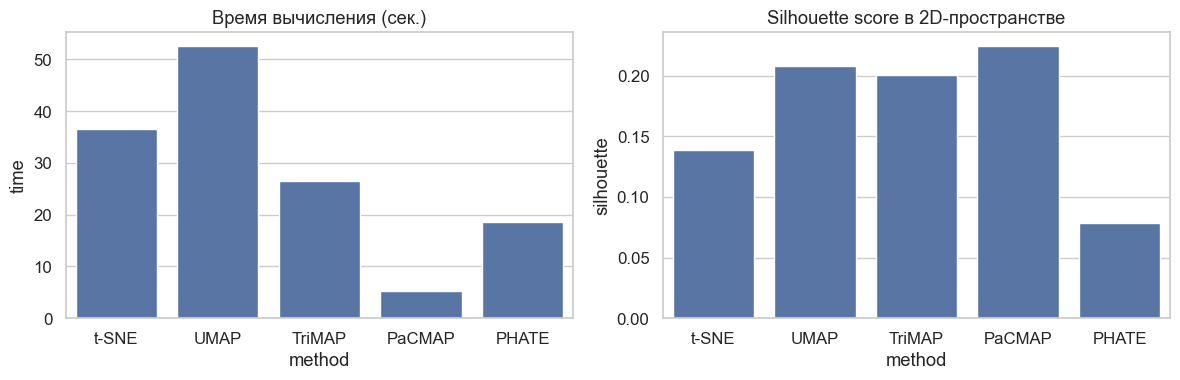

In [11]:
# Небольшая визуализация сравнения по времени и silhouette

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="method", y="time", ax=axes[0])
axes[0].set_title("Время вычисления (сек.)")

sns.barplot(data=df, x="method", y="silhouette", ax=axes[1])
axes[1].set_title("Silhouette score в 2D-пространстве")

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 7. Влияние препроцессинга: Raw vs StandardScaler vs PCA+StandardScaler
# ============================================================

# Для ускорения сравним только UMAP и PaCMAP в разных вариантах препроцессинга

X_raw_small = X_raw
X_std_small = X_std
X_pca = PCA(n_components=50, random_state=42).fit_transform(X_std)

preproc_variants = {
    "raw": X_raw_small,
    "standard": X_std_small,
    "pca50_std": X_pca,
}

summary = []

for name, X_cur in preproc_variants.items():
    print(f"\n=== Preprocessing: {name} ===")

    Z_umap_pp, t_umap_pp = embed_and_time(
        f"UMAP ({name})",
        lambda X, **kw: umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            random_state=42,
        ).fit_transform(X),
        X_cur,
    )
    sil_umap_pp = silhouette_score(Z_umap_pp, y)
    knn_umap_pp = knn_preservation(X_cur, Z_umap_pp, n_neighbors=15)

    Z_pacmap_pp, t_pacmap_pp = embed_and_time(
        f"PaCMAP ({name})",
        lambda X, **kw: pacmap.PaCMAP(
            n_components=2,
            n_neighbors=15,
            random_state=42,
        ).fit_transform(X),
        X_cur,
    )
    sil_pacmap_pp = silhouette_score(Z_pacmap_pp, y)
    knn_pacmap_pp = knn_preservation(X_cur, Z_pacmap_pp, n_neighbors=15)

    summary.append(
        dict(
            preproc=name,
            method="UMAP",
            time=t_umap_pp,
            silhouette=sil_umap_pp,
            knn_pres=knn_umap_pp,
        )
    )
    summary.append(
        dict(
            preproc=name,
            method="PaCMAP",
            time=t_pacmap_pp,
            silhouette=sil_pacmap_pp,
            knn_pres=knn_pacmap_pp,
        )
    )



=== Preprocessing: raw ===


e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (raw): 30.52 s


PaCMAP (raw): 5.34 s

=== Preprocessing: standard ===


e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (standard): 36.72 s


PaCMAP (standard): 8.09 s

=== Preprocessing: pca50_std ===


e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (pca50_std): 66.30 s


PaCMAP (pca50_std): 3.77 s


In [13]:
# Таблица с влиянием препроцессинга
df_pp = pd.DataFrame(summary)
df_pp


,preproc,method,time,silhouette,knn_pres
0,raw,UMAP,30.523598,0.270521,0.294633
1,raw,PaCMAP,5.343222,0.304735,0.260650
2,standard,UMAP,36.716464,0.208083,0.301717
3,standard,PaCMAP,8.087724,0.224747,0.271617
4,pca50_std,UMAP,66.302970,0.228376,0.328983
5,pca50_std,PaCMAP,3.771552,0.230365,0.285800


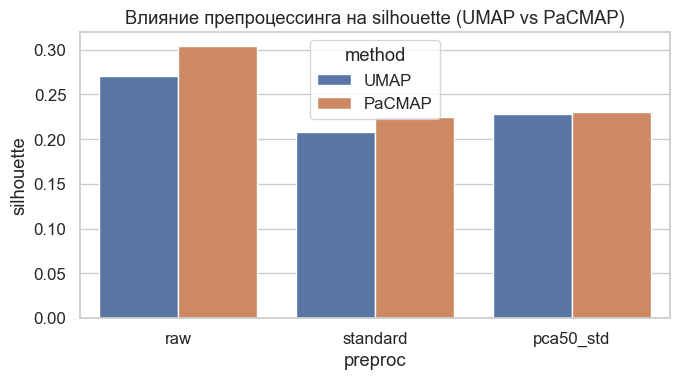

In [14]:
# График: silhouette для UMAP и PaCMAP при разных препроцессингах

plt.figure(figsize=(7, 4))
sns.barplot(data=df_pp, x="preproc", y="silhouette", hue="method")
plt.title("Влияние препроцессинга на silhouette (UMAP vs PaCMAP)")
plt.tight_layout()
plt.show()
